# Notebook 02: Modeling

---

## Objective

Build an end-to-end machine learning model to predict the probability of a patient developing coronary heart disease in 10 years.

---

## Data Source

This project uses the Framingham Heart Study dataset, a cleaned subset commonly used for cardiovascular risk prediction.

**Features:** 15 clinical and demographic variables.   
**Target:** TenYearCHD (10-year risk of coronary heart disease)   
**Samples:** 4,238 patients

---

## Table of Contents

1. [Import Libraries](#1-import-libraries)   
2. [Load Data](#2-load-data)    
3. [Train-Val-Test Split](#3-train-val-test-split)    
4. [Define Preprocessing & Pipelines](#4-define-preprocessing--pipelines)    
4.1 [Preprocessing Steps](#41-preprocessing-steps)   
4.2 [Logistic Regression Pipeline](#42-logistic-regression-pipeline)   
4.3 [XGBoost Pipeline](#43-xgboost-pipeline)   
5. [Model Training](#5-model-training)   
5.1 [Logistic Regression](#51-logistic-regression)   
5.2 [XGBoost](#52-xgboost)
6. [Hyperparameter Tuning](#6-hyperparameter-tuning)   
6.1 [Logistic Regression Hyperparameter Tuning](#61-logistic-regression-hyperparameter-tuning)   
6.2 [XGBoost Hyperparameter Tuning](#62-xgboost-hyperparameter-tuning)
7. [Threshold Tuning](#7-threshold-tuning)   
7.1 [Logistic Regression Threshold Tuning](#71-logistic-regression-threshold-tuning)   
7.2 [XGBoost Threshold Tuning](#72-xgboost-threshold-tuning)   
7.3 [Create Full Training Data & Save](#73-create-full-training-data--save)    
7.4 [Retrain Models on Full Train Set](#74-retrain-models-on-full-train-set)
8. [Model Evaluation & Comparison](#8-model-evaluation--comparison)   
8.1 [Calculate Metrics (ROC-AUC, KS, Precision, Recall)](#81-calculate-metrics-roc-auc-ks-precision-recall)   
8.2 [ROC Curves](#82-roc-curves)   
8.3 [Precision-Recall Curves](#83-precision-recall-curves)
9. [Model Interpretation](#9-model-comparison--final-model-selection)    
9.1 [Logistic Regression Feature Importance](#91-logistic-regression-feature-importance)    
9.2 [XGBoost Feature Importance](#92-xgboost-feature-importance)
10. [Discussion & Next Steps](#10-discussion--next-steps)

## 1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV 
from sklearn.preprocessing import StandardScaler 
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score
)
from scipy.stats import ks_2samp, uniform, loguniform

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import shap

from tqdm.notebook import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv("../data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Train-Val-Test Split

In [3]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (3178, 15), (3178,)
Validation set shape: (530, 15), (530,)
Test set shape: (530, 15), (530,)


## 4. Define Preprocessing & Pipelines

### 4.1 Preprocessing Steps

Logistic Regression is a **linear model** and is sensitive to feature scaling and extreme values, and requires imputation. 

XGBoost is a **tree-based gradient boosting model** and is robust to feature scaling and missing values, but still benefits from outlier handling.

Both models will share *feature engineering* and *winsorization*, but will differ in later preprocessing steps.

`Logistic Regression`:   
- Feature Engineering
- Numerical Imputation (median)
- Winsorization (to reduce impact of outliers)
- Numerical Scaling (StandardScaler)
- Categorical Imputation (most frequent)

`XGBoost`:
- Feature Engineering 
- Winsorization

In [4]:
# Define feature groups
NUM_FEATURES = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "MAP", "pulse_pressure"]
CAT_FEATURES = ["male", "education", "BPMeds", "prevalentStroke", "currentSmoker", "prevalentHyp", "diabetes"]

In [5]:
# Define custom transformers for winsorization and feature engineering
class Winsorizer(BaseEstimator, TransformerMixin):
    """Create a custom transformer to perform winsorization on numerical features."""
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        self.lower_bounds_ = np.quantile(X, self.lower_quantile, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper_quantile, axis=0)
        return self
    
    def transform(self, X):
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)
    
    def set_output(self, transform=None):
        """Set the output of the transformer to a pandas DataFrame."""
        return self
    
class FeatureEngineering(BaseEstimator, TransformerMixin):
    """Create a custom transformer to perform feature engineering."""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_fe = X.copy()
        X_fe["pulse_pressure"] = X_fe["sysBP"] - X_fe["diaBP"]
        X_fe["MAP"] = (X_fe["sysBP"] + 2 * X_fe["diaBP"]) / 3
        return X_fe
    
    def set_output(self, transform=None):
        """Set the output of the transformer to a pandas DataFrame."""
        return self

### 4.2 Logistic Regression Pipeline

In [6]:
def build_logreg_pipeline(model=None):
    """Builds a pipeline for logistic regression with feature engineering, preprocessing, and model."""
    return Pipeline([
        # Apply feature engineering before preprocessing
        ("feature_engineering", FeatureEngineering()),
        ("preprocessor", ColumnTransformer([
            ("num", Pipeline([
                # Impute missing values with median
                ("imputation", SimpleImputer(strategy="median")),
                # Apply winsorization to handle outliers
                ("winsorizer", Winsorizer()),
                # Scale numerical features
                ("scaler", StandardScaler())
            ]), NUM_FEATURES),
            # Impute categorical features with the most frequent value
            ("cat", SimpleImputer(strategy="most_frequent"), CAT_FEATURES)
        ])),
        ("model", model)
    ]).set_output(transform="pandas")

### 4.3 XBGoost Pipeline

In [7]:
def build_xgb_pipeline(model=None):
    """Builds a pipeline for XGBoost with feature engineering, preprocessing, and model."""
    return Pipeline([
        # Apply feature engineering before preprocessing
        ("feature_engineering", FeatureEngineering()),
        ("preprocessor", ColumnTransformer([
            ("num", Pipeline([
                # Apply winsorization to handle outliers
                ("winsorizer", Winsorizer()),    
            ]), NUM_FEATURES),
        ("cat", "passthrough", CAT_FEATURES)
        ])),
        ("model", model)
    ]).set_output(transform="pandas")

## 5. Model Training

### 5.1 Logistic Regression

Regularized Logistic Regression (L2 Penalty)

In [8]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define function to summarize cross-val results
def summarize_cv(results):
    """Summarizes cross-validation results by calculating mean scores for each metric. """
    return pd.DataFrame({
        "metric": ["roc_auc", "precision", "recall", "f1", "time"],
        "train_mean": [ 
            results["train_roc_auc"].mean(),
            results["train_precision"].mean(),
            results["train_recall"].mean(),
            results["train_f1"].mean(),
            results["fit_time"].mean()
        ],
        "test_mean": [
            results["test_roc_auc"].mean(),
            results["test_precision"].mean(),
            results["test_recall"].mean(),
            results["test_f1"].mean(),
            results["score_time"].mean()
        ]
    })

In [9]:
# Define Baseline Logistic Regression model
baseline_logreg_model = LogisticRegression(
    l1_ratio=0, # l2 regularization
    solver="saga",
    class_weight={0: 1, 1: 5}, 
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Build Logistic Regression pipeline
logreg_pipeline = build_logreg_pipeline(model=baseline_logreg_model)

# Evaluate Logistic Regression using cross-validation
logreg_cv_results = cross_validate(
    logreg_pipeline, 
    X_train, y_train, 
    cv=cv, 
    scoring=["roc_auc", "precision", "recall", "f1"],
    return_train_score=True
)

In [10]:
summarize_cv(logreg_cv_results)

,metric,train_mean,test_mean
0,roc_auc,0.744954,0.730884
1,precision,0.297074,0.287597
2,recall,0.663042,0.643943
3,f1,0.410277,0.397468
4,time,0.044186,0.015194


### 5.2 XGBoost

Regularized gradient boosted decision trees (XGBoost) optimizing auc with subsampling and shallow trees to reduce overfitting

In [11]:
baseline_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=10,
    scale_pos_weight=5,
    random_state=RANDOM_STATE
)

# Build the pipeline
xgb_pipeline = build_xgb_pipeline(model=baseline_xgb_model)

# Apply cross-validation to evaluate the model
xgb_cv_results = cross_validate(
    xgb_pipeline, 
    X_train, y_train, 
    cv=cv, 
    scoring=["roc_auc", "precision", "recall", "f1"],
    return_train_score=True
)

In [12]:
summarize_cv(xgb_cv_results)

,metric,train_mean,test_mean
0,roc_auc,0.806335,0.723698
1,precision,0.340143,0.278008
2,recall,0.723087,0.583806
3,f1,0.462481,0.376338
4,time,0.080814,0.020912


`Logistic Regression`   
Train and test cross-validation results indicate that the baseline Logistic Regression model generalizes well, its train and validation metrics are relatively close across folds.

* **ROC-AUC**: The model demonstrates reasonable class separation with a cross-validated ROC-AUC of 0.731.
* **Precision**: Precision is moderate at (~29%) given the imbalance, indicating that when the model predicts CHD, it is correct roughly one third of the time.
* **Recall**: The model identified approximately 65% of all CHD cases, which is important for a medical prediction task where failing to detect disease could be costly.

We must balance precision and recall. Achieving high recall would mean that our model identifies most CHD cases but this may be at the cost of many false positives, while high precision would mean that the model predicts CHD only when it is very certain but would lead to many missed positive cases. 

`XGBoost` 

* **ROC-AUC**: The XGBoost model achieves a cross-validated ROC-AUC of approximately 0.72, which is slightly below Logistic Regression. The train ROC_AUC (0.81) is moderately higher than the validation ROC-AUC (0.72) indicating mild overfit.
* **Precision and Recall**: Precision and recall are similar to Logistic Regression but Logistic Regression performs slightly better.

XGBoost performs similarly to Logistic Regression but the linear model slightly outperforms it across all metrics, including generalization and inference time.


## 6. Hyperparameter Tuning

### 6.1 Logistic Regression Hyperparameter Tuning

In [13]:
# Define Logistic Regression model for hyperparameter tuning
logreg_model = LogisticRegression(
    solver="saga",
    max_iter=10000,
    tol=1e-3,
    random_state=RANDOM_STATE
)

# Build the pipeline for hyperparameter tuning
logreg_tuning_pipeline = build_logreg_pipeline(model=logreg_model)

# Define the hyperparameter search space
param_dist = {
    "model__C": loguniform(1e-4, 1e4),
    "model__l1_ratio": np.linspace(0, 1, 20),
    "model__class_weight": [None, 
                            "balanced",
                            {0: 1, 1: 3}, 
                            {0: 1, 1: 5},
                            {0: 1, 1: 10}]
}

# Set up RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=logreg_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=80, 
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Display best hyperparameters and best score for Logistic Regression
print("Best Hyperparameters:", random_search.best_params_)
print("Best ROC AUC Score:", random_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'model__C': np.float64(2.077480993119357), 'model__class_weight': 'balanced', 'model__l1_ratio': np.float64(0.631578947368421)}
Best ROC AUC Score: 0.7310622796447539


In [14]:
# Save best Logistic Regression model
best_logreg_model = random_search.best_estimator_

### 6.2 XGBoost Hyperparameter Tuning

In [15]:
# Define the XGBoost model for hyperparameter tuning
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE
)

# Define the hyperparameter search space for XGBoost
param_dist = {
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__learning_rate": uniform(0.02, 0.10),
    "model__n_estimators": [100, 250, 500, 750], 
    "model__subsample": [0.5, 0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__reg_lambda": [1, 3, 5],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__gamma": [0, 0.1, 0.25, 0.5],
    "model__scale_pos_weight": [1, 3, 5, 7, 10]
}

# Build the pipeline for hyperparameter tuning
xgb_tuning_pipeline = build_xgb_pipeline(model=xgb_model)

# Set up RandomizedSearchCV for hyperparameter tuning of XGBoost
random_search = RandomizedSearchCV(
    xgb_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=80,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit the RandomizedSearchCV to the training data for XGBoost
random_search.fit(X_train, y_train)

# Display best hyperparameters and best score for XGBoost
print("Best Hyperparameters:", random_search.best_params_)
print("Best ROC AUC Score:", random_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'model__colsample_bytree': 0.8, 'model__gamma': 0.25, 'model__learning_rate': np.float64(0.06972485058923855), 'model__max_depth': 2, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__scale_pos_weight': 1, 'model__subsample': 0.7}
Best ROC AUC Score: 0.7284782657205338


In [16]:
# Save the best model from RandomizedSearchCV
best_xgb_model = random_search.best_estimator_

## 7. Threshold Tuning

Using the default classification threshold of .50 is usually not ideal, espeically in medical contexts. For this reason, the classification threshold will be tuned for each model on the validation set by optimizing **F1 score**. The F1 metric is chosen because it balances precision and recall. 

### 7.1 Logistic Regression Threshold Tuning

In [17]:
def generate_classification_report(y_true, y_pred):
    """Generates a classification report with precision, recall, f1-score, and support."""
    report = classification_report(y_true, y_pred)
    return report   

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save=False):
    """Plots a confusion matrix using seaborn heatmap."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    if save:
        fig.savefig(f"../artifacts/confusion_matrix_{title.replace(' ', '_')}.png")

    plt.show()
    plt.close(fig)

def plot_best_threshold(title, thresholds, precision_scores, recall_scores, f1_scores, best_threshold, save=False):
    """Plots precision, recall, and F1-score across different thresholds with the best threshold highlighted."""

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(thresholds, precision_scores, label="Precision", color="blue")
    ax.plot(thresholds, recall_scores, label="Recall", color="orange")
    ax.plot(thresholds, f1_scores, label="F1 Score", color="green")

    ax.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(title)

    ax.legend()
    ax.grid()

    if save:
        fig.savefig(f"../artifacts/threshold_tuning_plot_{best_threshold:.2f}.png")
    plt.show()
    plt.close(fig)

def tune_threshold(model, X, y, title, save=False):
    """Tunes the classification threshold to optimize F1-score."""
    thresholds = np.arange(0.0, 1.01, 0.005)
    best_f1 = -1
    best_threshold = 0 

    recall_scores = list()
    precision_scores = list()
    f1_scores = list()

    y_proba = model.predict_proba(X)[:, 1]

    for t in thresholds:
        y_pred_at_t = (y_proba >= t).astype(int)

        precision = precision_score(y, y_pred_at_t, zero_division=0)
        recall = recall_score(y, y_pred_at_t)
        f1 = f1_score(y, y_pred_at_t, zero_division=0)

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1) 

        if f1 > best_f1:
            best_f1 = f1 
            best_threshold = t
            print(f"Threshold: {t:.2f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    print(f"\nBest Threshold: {best_threshold:.2f} with F1-score: {best_f1:.4f}")
    plot_best_threshold(title, thresholds, precision_scores, recall_scores, f1_scores, best_threshold, save)

In [18]:
# Predict on Val-set using the best Logistic Regression model
y_pred = best_logreg_model.predict(X_val)

In [19]:
# Generate Classification Report for Logistic Regression on Validation Set
print("Classification Report for Logistic Regression on Validation Set - Threshold 0.5:")
print("=" * 80)
print(generate_classification_report(y_val, y_pred))

Classification Report for Logistic Regression on Validation Set - Threshold 0.5:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       449
           1       0.25      0.59      0.35        81

    accuracy                           0.66       530
   macro avg       0.57      0.63      0.56       530
weighted avg       0.80      0.66      0.71       530



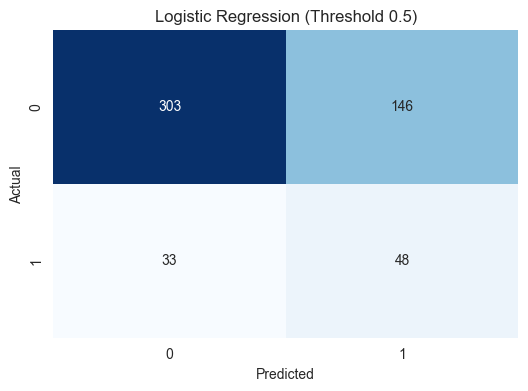

In [20]:
# Generate Confusion Matrix for Logistic Regression on Validation Set 
plot_confusion_matrix(y_val, y_pred, title="Logistic Regression (Threshold 0.5)", save=True)

Threshold: 0.00, Precision: 0.1528, Recall: 1.0000, F1-score: 0.2651
Threshold: 0.08, Precision: 0.1531, Recall: 1.0000, F1-score: 0.2656
Threshold: 0.10, Precision: 0.1534, Recall: 1.0000, F1-score: 0.2660
Threshold: 0.10, Precision: 0.1546, Recall: 1.0000, F1-score: 0.2678
Threshold: 0.10, Precision: 0.1555, Recall: 1.0000, F1-score: 0.2691
Threshold: 0.11, Precision: 0.1561, Recall: 1.0000, F1-score: 0.2700
Threshold: 0.12, Precision: 0.1570, Recall: 1.0000, F1-score: 0.2714
Threshold: 0.12, Precision: 0.1573, Recall: 1.0000, F1-score: 0.2718
Threshold: 0.13, Precision: 0.1579, Recall: 1.0000, F1-score: 0.2727
Threshold: 0.14, Precision: 0.1601, Recall: 1.0000, F1-score: 0.2760
Threshold: 0.14, Precision: 0.1610, Recall: 1.0000, F1-score: 0.2774
Threshold: 0.14, Precision: 0.1630, Recall: 1.0000, F1-score: 0.2803
Threshold: 0.15, Precision: 0.1636, Recall: 1.0000, F1-score: 0.2812
Threshold: 0.15, Precision: 0.1640, Recall: 1.0000, F1-score: 0.2817
Threshold: 0.16, Precision: 0.1650

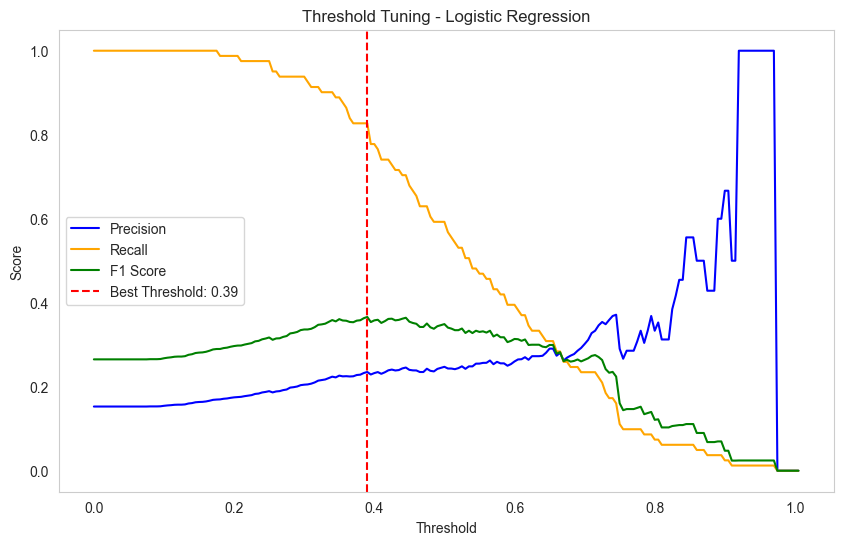

In [21]:
# Tune the classification threshold for the best Logistic Regression model
tune_threshold(best_logreg_model, X_val, y_val, title="Threshold Tuning - Logistic Regression", save=True)

In [22]:
# Set optimal threshold based on tuning results
optimal_threshold_logreg = 0.39

# Predict on Val-set using the best Logistic Regression model with optimal threshold (.39)
y_pred = (best_logreg_model.predict_proba(X_val)[:, 1] >= optimal_threshold_logreg).astype(int)

In [23]:
# Generate Classification Report for Logistic Regression on Validation Set
print(f"Classification Report for Logistic Regression on Validation Set - Threshold {optimal_threshold_logreg}:")
print("=" * 80)
print(generate_classification_report(y_val, y_pred))

Classification Report for Logistic Regression on Validation Set - Threshold 0.39:
              precision    recall  f1-score   support

           0       0.94      0.51      0.67       449
           1       0.24      0.83      0.37        81

    accuracy                           0.56       530
   macro avg       0.59      0.67      0.52       530
weighted avg       0.83      0.56      0.62       530



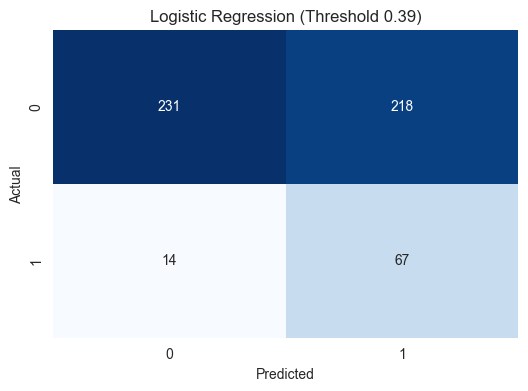

In [24]:
# Generate Confusion Matrix for Logistic Regression on Validation Set 
plot_confusion_matrix(y_val, y_pred, title=f"Logistic Regression (Threshold {optimal_threshold_logreg})", save=True)

### 7.2 XGBoost Threshold Tuning

In [25]:
# Predict on Val-set using the best XGBoost model 
y_pred = best_xgb_model.predict(X_val)

In [26]:
# Generate Classification Report for XGBoost on Validation Set
print("Classification Report for XGBoost on Validation Set - Threshold 0.5:")
print("=" * 80)
print(generate_classification_report(y_val, y_pred))

Classification Report for XGBoost on Validation Set - Threshold 0.5:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       449
           1       0.50      0.05      0.09        81

    accuracy                           0.85       530
   macro avg       0.68      0.52      0.50       530
weighted avg       0.80      0.85      0.79       530



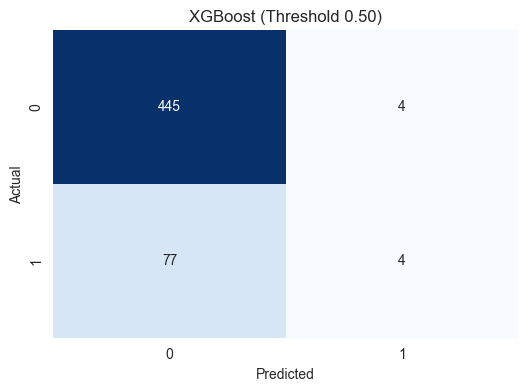

In [27]:
# Generate Confusion Matrix for XGBoost on Validation Set 
plot_confusion_matrix(y_val, y_pred, title=f"XGBoost (Threshold 0.50)", save=True)

Threshold: 0.00, Precision: 0.1528, Recall: 1.0000, F1-score: 0.2651
Threshold: 0.03, Precision: 0.1534, Recall: 1.0000, F1-score: 0.2660
Threshold: 0.03, Precision: 0.1570, Recall: 1.0000, F1-score: 0.2714
Threshold: 0.04, Precision: 0.1640, Recall: 1.0000, F1-score: 0.2817
Threshold: 0.04, Precision: 0.1698, Recall: 1.0000, F1-score: 0.2903
Threshold: 0.04, Precision: 0.1717, Recall: 0.9753, F1-score: 0.2921
Threshold: 0.05, Precision: 0.1791, Recall: 0.9753, F1-score: 0.3027
Threshold: 0.06, Precision: 0.1847, Recall: 0.9506, F1-score: 0.3092
Threshold: 0.06, Precision: 0.1901, Recall: 0.9506, F1-score: 0.3169
Threshold: 0.07, Precision: 0.1913, Recall: 0.9259, F1-score: 0.3171
Threshold: 0.07, Precision: 0.1989, Recall: 0.9136, F1-score: 0.3267
Threshold: 0.07, Precision: 0.2068, Recall: 0.9012, F1-score: 0.3364
Threshold: 0.08, Precision: 0.2135, Recall: 0.9012, F1-score: 0.3452
Threshold: 0.09, Precision: 0.2182, Recall: 0.8889, F1-score: 0.3504
Threshold: 0.09, Precision: 0.2250

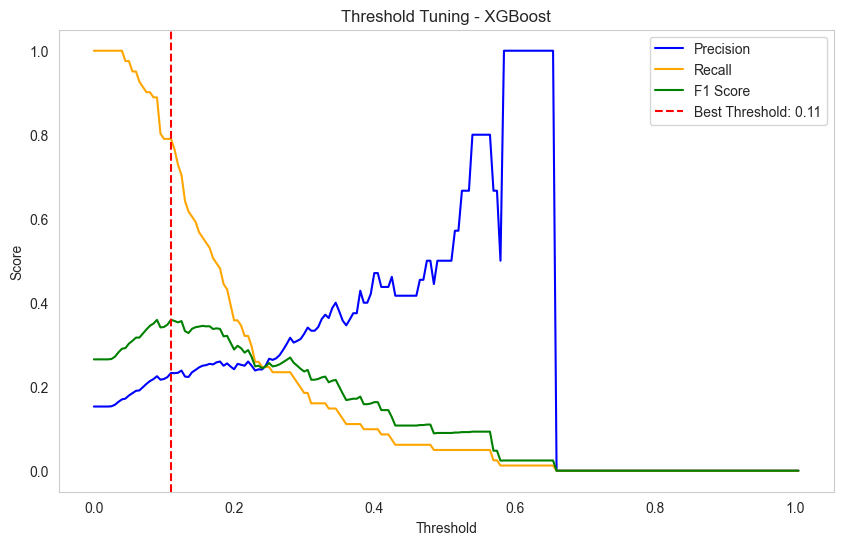

In [28]:
# Tune the classification threshold for the best XGBoost model
tune_threshold(best_xgb_model, X_val, y_val, title="Threshold Tuning - XGBoost", save=True)

In [29]:
# Set optimal threshold based on tuning results
optimal_threshold_xgb = 0.11

# Predict on Val-set using the best XGBoost model with optimal threshold
y_pred = (best_xgb_model.predict_proba(X_val)[:, 1] >= optimal_threshold_xgb).astype(int)

In [30]:
# Generate Classification Report for XGBoost on Validation Set
print(f"Classification Report for XGBoost on Validation Set - Threshold {optimal_threshold_xgb}:")
print("=" * 80)
print(generate_classification_report(y_val, y_pred))

Classification Report for XGBoost on Validation Set - Threshold 0.11:
              precision    recall  f1-score   support

           0       0.93      0.53      0.68       449
           1       0.23      0.79      0.36        81

    accuracy                           0.57       530
   macro avg       0.58      0.66      0.52       530
weighted avg       0.83      0.57      0.63       530



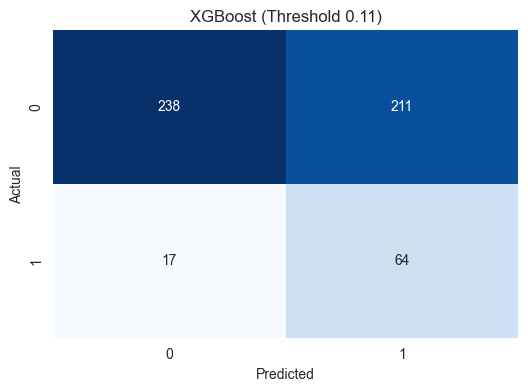

In [31]:
# Generate Confusion Matrix for XGBoost on Validation Set 
plot_confusion_matrix(y_val, y_pred, title=f"XGBoost (Threshold {optimal_threshold_xgb})", save=True)

### 7.3 Create Full Training Data & Save

In [32]:
# Combine training and validation sets for final model training
X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(f"Full Training set shape: {X_train_full.shape}, {y_train_full.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Full Training set shape: (3708, 15), (3708,)
Test set shape: (530, 15), (530,)


In [33]:
# Combine features and target into a single DataFrame for training and testing sets
train_df = pd.concat([X_train_full, y_train_full], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Save training and test sets to CSV files
train_df.to_csv("../data/train.csv", index=False, mode="w")
test_df.to_csv("../data/test.csv", index=False, mode="w")

### 7.4 Retrain Models on Full Train Set

In [34]:
# Train the best Logistic Regression model on the full training data
best_logreg_model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [35]:
# Train the best XGBoost model on the full training data
best_xgb_model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

## 8. Model Evaluation & Comparison

### 8.1 Calculate Metrics (ROC-AUC, KS, Precision, Recall)

In [36]:
def compute_test_metrics(model, X, y, threshold):
    """Computes the precision, recall, F1-score, and ROC AUC."""
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y, y_proba)

    return {"Threshold": threshold,
            "ROC AUC": roc_auc,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        }

def compute_ks_statistic(model, X, y):
    """Computes the KS statistic and p-value for the model's predicted probabilities."""
    y_proba = model.predict_proba(X)[:, 1]
    proba_pos = y_proba[y == 1]
    proba_neg = y_proba[y == 0]
    ks_statistic, p_value = ks_2samp(proba_pos, proba_neg)
    return ks_statistic, p_value

In [37]:
logreg_performance = compute_test_metrics(best_logreg_model, X_test, y_test, optimal_threshold_logreg)
xgb_performance = compute_test_metrics(best_xgb_model, X_test, y_test, optimal_threshold_xgb)

print("Test Set Performance:")
pd.DataFrame([logreg_performance, xgb_performance], index=["Logistic Regression", "XGBoost"])


Test Set Performance:


,Threshold,ROC AUC,Precision,Recall,F1-score
Logistic Regression,0.39,0.694944,0.210345,0.7625,0.329730
XGBoost,0.11,0.682389,0.207612,0.7500,0.325203


In [38]:
print("\nKS Statistic and p-value for Logistic Regression:")
ks_stat_logreg, p_value_logreg = compute_ks_statistic(best_logreg_model, X_test, y_test)
print(f"KS Statistic: {ks_stat_logreg:.4f}, p-value: {p_value_logreg:.4f}")


KS Statistic and p-value for Logistic Regression:
KS Statistic: 0.3131, p-value: 0.0000


In [39]:
print("\nKS Statistic and p-value for XGBoost:")
ks_stat_xgb, p_value_xgb = compute_ks_statistic(best_xgb_model, X_test, y_test)
print(f"KS Statistic: {ks_stat_xgb:.4f}, p-value: {p_value_xgb:.4f}")


KS Statistic and p-value for XGBoost:
KS Statistic: 0.2792, p-value: 0.0000


**Test Set Performance Summary**   
Both models were hyperparameter tuned using 5-fold cross-validation, and classification thresholds were chosen to maximize the F1-score on a held-out validation set. The training and validation sets were then combined into train_set_full to retrain the hyperparameter tuned models.

The metrics reported above reflect performance on a held-out test set, evaluated using both threshold-independent and threshold-dependent metrics.

---

**Threshold-independent Metrics**    
The Logistic Regression model demonstrates slightly stronger class seperation based on **ROC-AUC** and the **Kolmogorov-Smirnov (KS)** statistic, which measures the maximum separation between the score distributions of the positivie and negative CHD classes.

Class Separation:
* ROC-AUC: ~0.69 (vs ~0.68 for XGBoost)
* KS Statistic: 0.31 (vs ~0.28 for XGBoost)

These results suggest that Logistic Regression produces slightly better separation between individuals who develop CHD and those who don't.

---

**Threshold-dependent Metrics**   

Logistic Regression achieves **higher recall**, identifying approximately **76% of CHD cases**, compared to ~**75% for XGBoost**.   
Both models achieve similar **precision at 21%**

---

**Model Selection**   
Based on overall performance on the test set, `Logistic Regression` is selected as the **champion model**.

The similar performance between Logistic Regression and XGBoost suggests that:
* Predictive signal in the available features is primarily linear
* Additional model complexity does not substantially improve predictive performance

### 8.2 ROC Curves

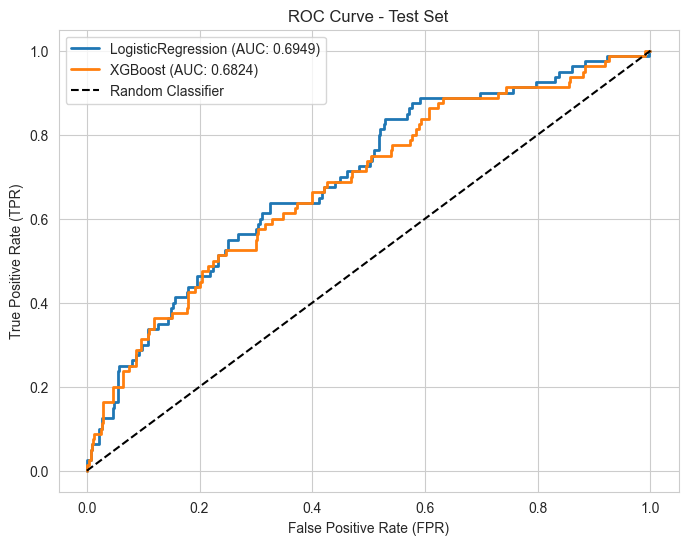

In [40]:
# Plot ROC curves for both models
## Predict probabilities for test using best logistic regression model and best XGBoost model
y_proba_logreg = best_logreg_model.predict_proba(X_test)[:, 1]
y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

## Compute ROC curve and AUC for Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

## Compute ROC curve and AUC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize = (8,6))
plt.plot(fpr_logreg, tpr_logreg, label = f"LogisticRegression (AUC: {auc_logreg:.4f})", linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label = f"XGBoost (AUC: {auc_xgb:.4f})", linewidth=2)
plt.plot([0,1], [0,1], "k--", label = "Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Test Set")
plt.legend(loc = "upper left")
plt.grid(True)
plt.savefig("../artifacts/roc_curve_comparison.png")
plt.show()

### 8.3 Precision-Recall Curves

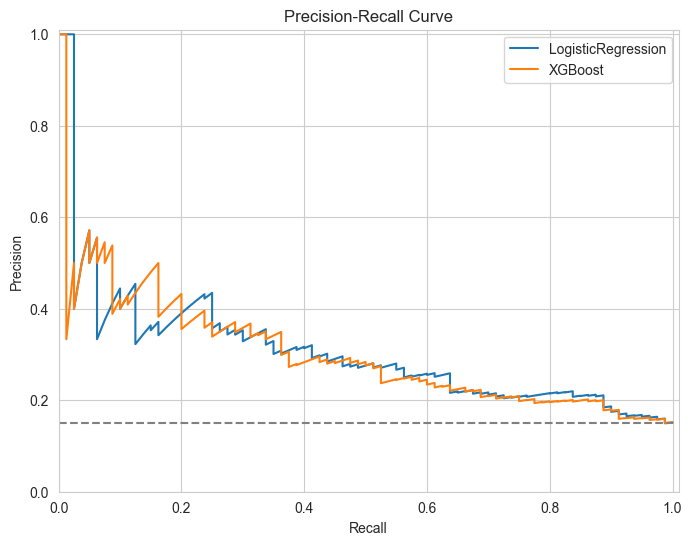

In [41]:
logreg_precision, logreg_recall, _ = precision_recall_curve(y_test, y_proba_logreg)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, y_proba_xgb)

baseline = y_test.mean()  

plt.figure(figsize = (8,6))
plt.plot(logreg_recall, logreg_precision, label = "LogisticRegression")
plt.plot(xgb_recall, xgb_precision, label = "XGBoost")
plt.hlines(baseline, xmin = 0, xmax = 1, linestyle = "dashed", color = "grey")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("../artifacts/precision_recall_curve_comparison.png")
plt.show()

The Precision-Recall curves show that both Logistic Regression and XGBoost provide modest predictive power above the baseline CHD prevalence (~15%). The curves largely overap, indicating that the additional complexity of XGBoost does not provide meaningful improvements over Logistic Regression. Precision declines steadily as recall increases, highlighting the trade-off between identifying more CHD cases and getting more false positives. These results suggest that the predictive signal in the available features is largely linear.

## 9. Model Interpretation

### 9.1 Logistic Regression Feature Importance

In [42]:
# Transform data using preprocessing steps
X_train_logreg_pre = best_logreg_model[:-1].transform(X_train)
X_val_logreg_pre = best_logreg_model[:-1].transform(X_val) 

In [43]:
# Apply SHAP
explainer_logreg = shap.LinearExplainer(
    best_logreg_model.named_steps["model"],
    X_train_logreg_pre
)

shap_values_logreg = explainer_logreg(X_val_logreg_pre)
shap.summary_plot(shap_values_logreg, features=X_val_logreg_pre, plot_type="bar", show=False)

plt.savefig("../artifacts/shap_summary_logreg.png", dpi=300, bbox_inches="tight")
plt.close()

### 9.2 XGBoost Feature Importance

In [44]:
# Transform data using preprocessing steps
X_train_xgb_pre = best_xgb_model[:-1].transform(X_train)
X_val_xgb_pre = best_xgb_model[:-1].transform(X_val) 

In [45]:
# Apply SHAP
explainer_xgb = shap.TreeExplainer(
    best_xgb_model.named_steps["model"],
    X_train_xgb_pre
)

shap_values_xgb = explainer_xgb(X_val_xgb_pre)
shap.summary_plot(shap_values_xgb, features=X_val_xgb_pre, plot_type="bar", show=False)

plt.savefig("../artifacts/shap_summary_xgb.png", dpi=300, bbox_inches="tight")
plt.close()

## 10. Discussion & Next Steps

### 10.1 Model Assumptions

`Logistic Regression`
* Linearity in the log-odds
    * Logistic Regression assumes a linear relationship between input features and the log-odds of CHD risk. Nonlinear relationships may not be fully captured without feature engineering.

* Independence of observations
    * Each patient is assumed to be independent, with no duplicate records or correlated observations (such as repeated measurements of the same individual). 

* Limited multicollinearity
    * Highly correlated features can lead to unstable coefficient estimates. Regularization (Elastic Net) helps mitigate this by shrinking coefficients.

* Binary response
    * The target variable is binary:
        * 1 - patient develops CHD within 10 years
        * 0 - patient does not develop CHD

`Tree-based models (e.g., XGBoost)`
Tree-based models are non-parametric and make fewer assumptions about feature distributions. However, they still rely on
* Independent and identically distributed observations.
* Sufficient data to learn meaningful splits
* No target leakage.

Unlike Logistic Regression, they can naturally capture nonlinear relationships and feature interactions.

**Data Assumptions**   
* No target leakage
    * Features must not contain information unavailable at prediction time.
* Correct labeling over a 10-year horizon
    * The outcome variable accurately reflects whether CHD occurred within the time window.
* Independence of observations
    * Each patient represents a unique data point.

### 10.2 Model Improvements
Several strategies could improve model performance.

1. Handling Class Imbalance     
The positive class (CHD) occurs in 15% of observations, making this an imbalanced classification problem.   
This creates a tradeoff between high recall (detecting more CHD cases) and low precision (more false positives). 

* Downsampling the majority class
* Upsampling the minority class (e.g., SMOTE)
* Adjusting class weights (already applied)


2. Additional Data
The dataset contains ~4000 observations, which is relatively small for complex models like XGBoost.

* Tree-based models generally benefit from larger data
* More data could improve generatlization and feature interactions

3. Ensemble Methods
Combining multiple models could also improve performance. Ensemble methods reduce variance and can capture both linear relationships and nonlinear patterns.

* Voting classifiers
* Stacking (Logreg + XGBoost)

### 10.3 Production Considerations
Deploying this model in a real-world setting requires model monitoring to ensure that model performance does not decline from changes in population health trends and shifts in feature distributions. Models should also be scalable and interpretable.

**Model Monitoring**
* Track prediction distributions over time
* Detect data drift (input feature shifts)
* Monitor performance degradation such as recall drop

**Scalability**
* API should handle batch predictions efficiently
* Consideration for containerization using Docker

**Interpretability** 
* Logistic Regression provides coefficient-level interpretability
* SHAP values also help explain feature importance

---

### 10.4 Summary

Logistic Regression was selected as the final model due to its test performance metrics and inference time. Theshold tuning (0.39) significantly improved recall, aligning the model with healthcare screening objectives. Feature engineering (MAP, pulse pressure) also added domain relevant signals and the final pipeline supports reproducible training and production inference via FastAPI.

---